# Project 21 : Compairing two given random requences
    - Author: Jingjing XU  /  Student ID: 0180092002  / University of Luxembourg
    - Advisor: Prof. Raymond Bisdorff
    
    - Description: This project concerns the validation or not of the claim that two given random sequences, X1 and X2, each of length 10000 : see http://sma.uni.lu/bisdorff/CompStatDec18/project-21Data.csv have been obtained from the same RNG.
    
    - Tasks:
        1. Compare statistically and graphically the two given random sequences X1 and X2.
        2. Are the given sequences X1 and X2 potentially drawn from the same RNG ?
        3. Motivate your answer with arguments taken from the Computational Statistics Course.
        
    - Content:
        1. get data
            1.1 Correlation Test
        2. Distribution Test
            2.1 Chi-squared Test（chisq.test）
            2.2 Kolmogorov–Smirnov test (ks.test)
            2.3 Empirical Tests
                2.3.1 Gap Test (gap.test)
                2.3.2 Serial Test (serial.test)
                2.3.3 Equidistribution Test (Frequence Test-freq.test)
   
        3. Conclusion
        4. Acknowledgement
        5. Reference

# 1 - get data

In [1]:
mydata = read.csv("project-21Data.csv")

In [163]:
mydata #each of length 10000

X1,X2
<dbl>,<dbl>
0.564245,0.573220
0.482677,0.590576
0.535010,0.575761
0.483634,0.027552
0.698641,0.738864
0.463605,0.080347
0.273774,0.819277
0.813865,0.910975
0.166370,0.682505


## 1.1 Correlation Test

In [41]:
library(ggplot2)

In [72]:
corr <- rep(0, 10000) 
for(i in seq(from = 1, to = 9900, by = 100)) {  
	corr[(i-1)/100] <-  cor.test(mydata$X1[i:(i+99)], mydata$X2[i:(i+99)])$estimate} 

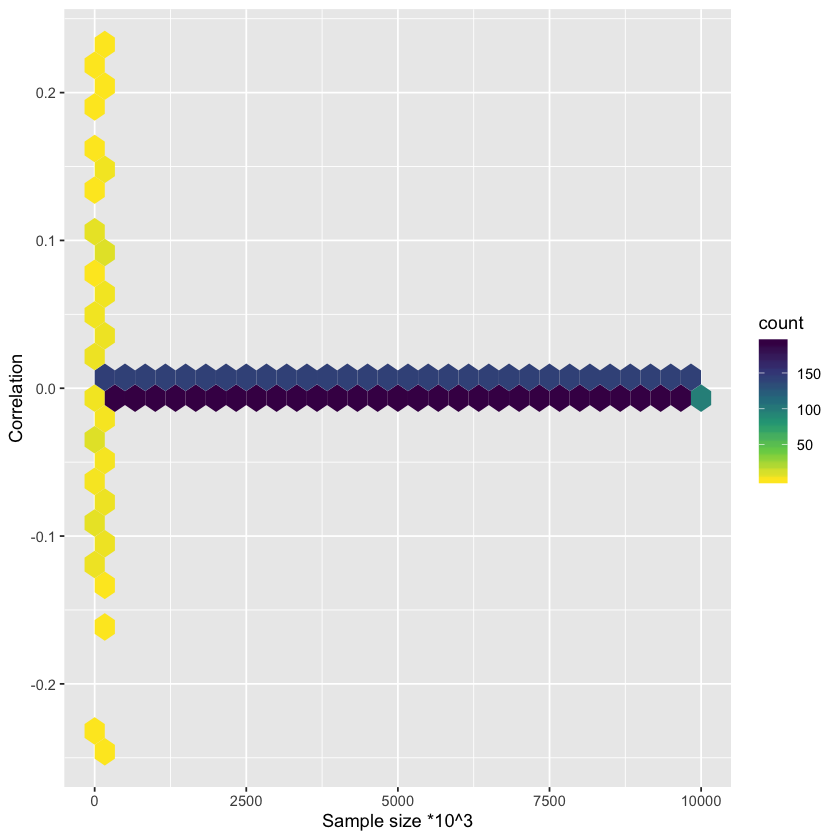

In [73]:
ggplot(data.frame(x = seq(10000), y = corr), aes(x = x, y = y)) +   
	geom_hex(show.legend = TRUE) + 
	scale_fill_viridis_c(direction = -1) + 
	xlab("Sample size *10^3") + ylab("Correlation") 

# 2 - test

## Test if the given data is a uniform distribution. 
##  2.1 Chi-squared Test（chisq.test）

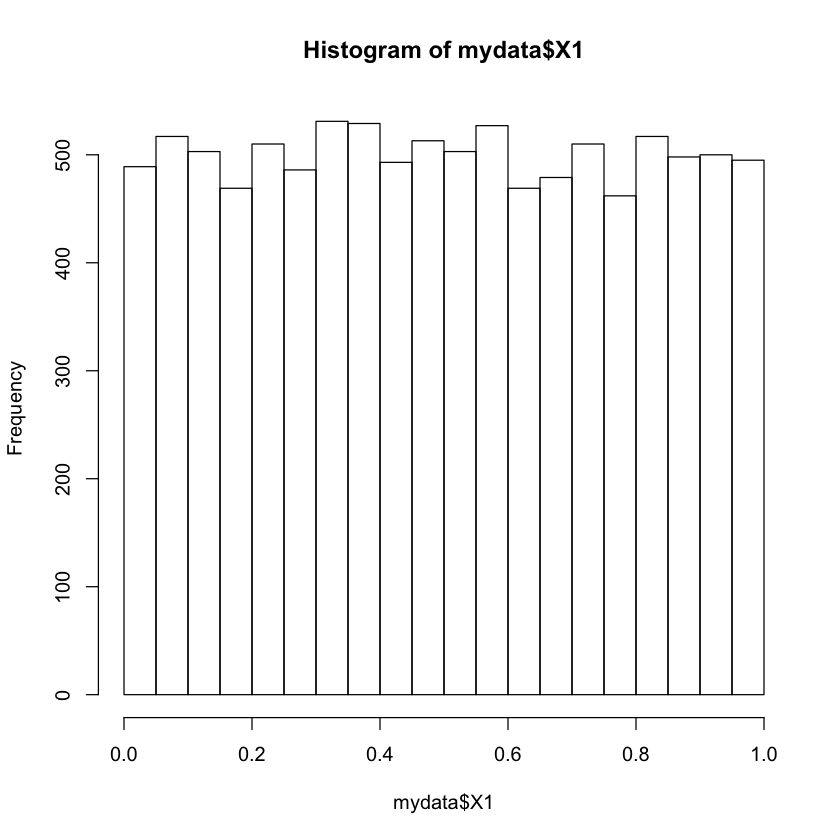

In [18]:
freq1 = hist(mydata$X1)

In [51]:
Ni1=freq1$counts

In [52]:
chisq.test(Ni1)


	Chi-squared test for given probabilities

data:  Ni1
X-squared = 15.396, df = 19, p-value = 0.6971


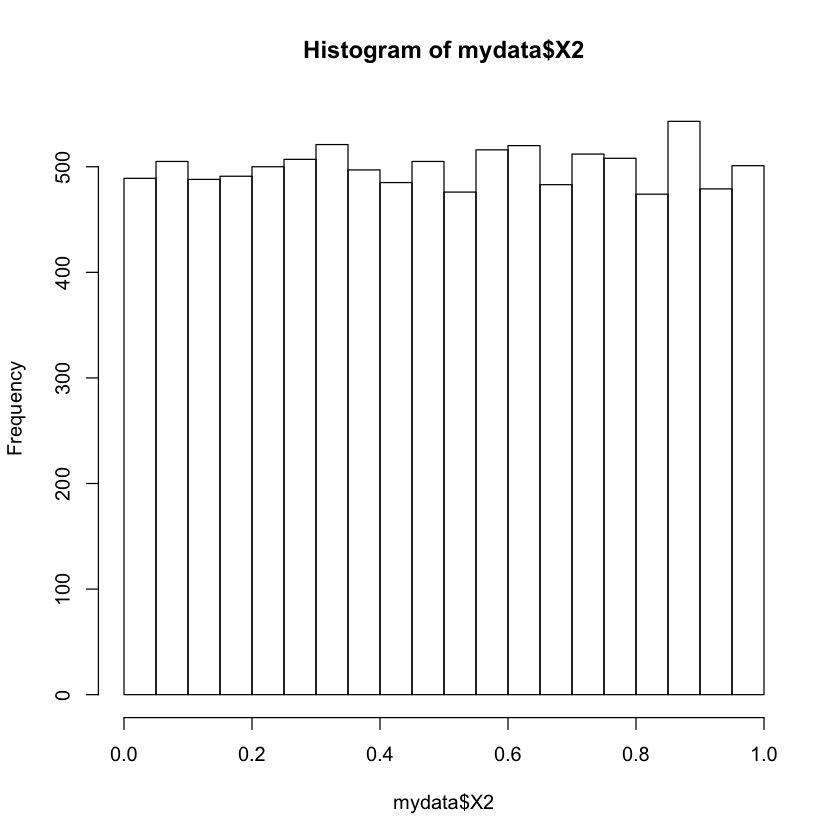

In [19]:
freq2 = hist(mydata$X2)

In [46]:
Ni2 = freq2$counts

In [63]:
chisq.test(Ni2)


	Chi-squared test for given probabilities

data:  Ni2
X-squared = 11.632, df = 19, p-value = 0.9007


In [134]:
rbind(Ni1, Ni2)

Ni1,489,517,503,469,510,486,531,529,493,513,503,527,469,479,510,462,517,498,500,495
Ni2,489,505,488,491,500,507,521,497,485,505,476,516,520,483,512,508,474,543,479,501


In [29]:
chisq.test(rbind(mydata$X1, mydata$X2))

Warning message in chisq.test(rbind(mydata$X1, mydata$X2)):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  rbind(mydata$X1, mydata$X2)
X-squared = 1801, df = 9999, p-value = 1


In [92]:
chisq.test(rbind(Ni1, Ni2))


	Pearson's Chi-squared test

data:  rbind(Ni1, Ni2)
X-squared = 12.627, df = 19, p-value = 0.8571


### - Conclusion 1: [Null hypothesis]: both samples come from the same distribution. [Result]: not rejected (p-value = 0.8571) since they do come from the exact same distribution.

##  2.2 Kolmogorov–Smirnov Test ( ks.test )

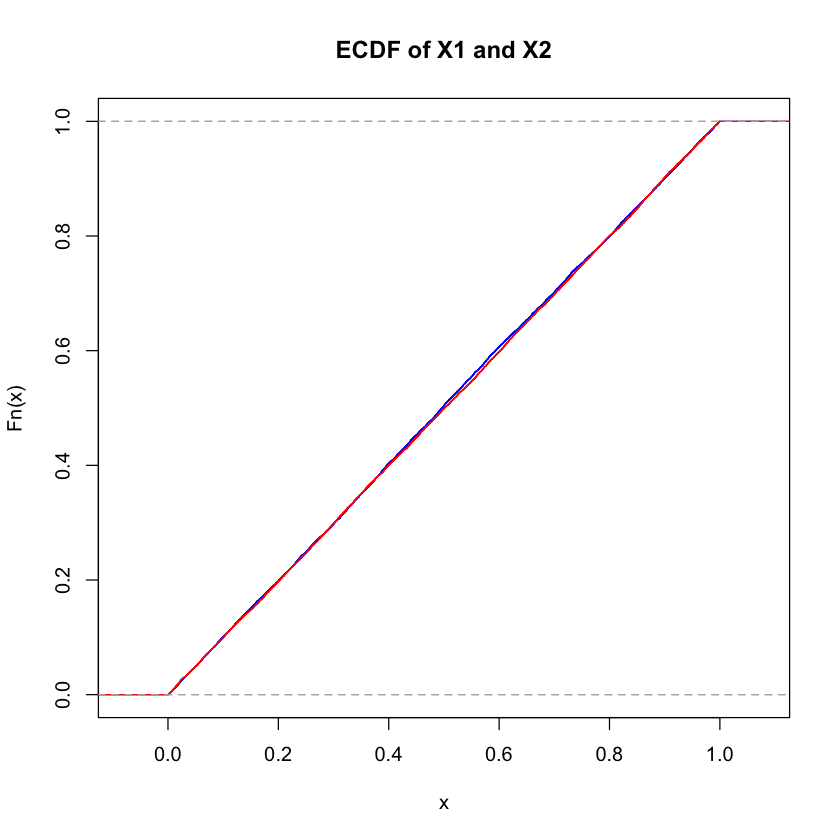

In [104]:
plot(ecdf(mydata$X1),col="blue", main = "ECDF of X1 and X2")
plot(ecdf(mydata$X2),add=T,col="red")

### - Conclusion 2: According to Cumulative Distribution Function showed above, the function is Uniform distribution (continuous)  unif(0,1)

In [57]:
ks.test(mydata$X1,mydata$X2)

Warning message in ks.test(mydata$X1, mydata$X2):
“p-value will be approximate in the presence of ties”



	Two-sample Kolmogorov-Smirnov test

data:  mydata$X1 and mydata$X2
D = 0.0099, p-value = 0.7112
alternative hypothesis: two-sided


### - Conclusion 3: “p-value will be approximate in the presence of ties”. The warning message is due to the implementation of the KS test in R, which expects a continuous distribution and thus there should not be any identical values in the two datasets i.e. ties. I’ve read several sources and they all mention that the KS test can deal with both discrete and continuous data (I’m guessing because it mainly deals with cumulative quantiles) but I’m not sure about the implementation in R. For more information[1], see this page http://www.physics.csbsju.edu/stats/KS-test.html.

## 2.3 Empirical Tests

### 2.3.1 Gap Tests

In [3]:
library(rngWELL)
library(randtoolbox)

In [6]:
gap1=gap.test(mydata$X1,0,0.5,echo = TRUE)


			 Gap test

chisq stat = 18, df = 13, p-value = 0.14

		 (sample size : 10000)

length	observed freq		theoretical freq
1 			 1165 			 1250 
2 			 640 			 625 
3 			 336 			 312 
4 			 149 			 156 
5 			 80 			 78 
6 			 43 			 39 
7 			 20 			 20 
8 			 6 			 9.8 
9 			 10 			 4.9 
10 			 2 			 2.4 
11 			 2 			 1.2 
12 			 0 			 0.61 
13 			 1 			 0.31 
14 			 0 			 0.15 


In [10]:
gap2=gap.test(mydata$X2,0,0.5,echo = TRUE)


			 Gap test

chisq stat = 6.3, df = 13, p-value = 0.94

		 (sample size : 10000)

length	observed freq		theoretical freq
1 			 1268 			 1250 
2 			 616 			 625 
3 			 302 			 312 
4 			 159 			 156 
5 			 77 			 78 
6 			 44 			 39 
7 			 17 			 20 
8 			 8 			 9.8 
9 			 3 			 4.9 
10 			 4 			 2.4 
11 			 2 			 1.2 
12 			 1 			 0.61 
13 			 1 			 0.31 
14 			 0 			 0.15 


### expected: expected counts under the null hypothesis.

In [14]:
expected_1=gap1$expected
expected_1

[1] 1250.00  625.00  312.50  156.25   78.12   39.06   19.53    9.77    4.88
[10]    2.44    1.22    0.61    0.31    0.15

In [15]:
expected_2=gap2$expected
expected_2

[1] 1250.00  625.00  312.50  156.25   78.12   39.06   19.53    9.77    4.88
[10]    2.44    1.22    0.61    0.31    0.15

In [34]:
rbind(gap1$observed, gap2$observed)

1165,640,336,149,80,43,20,6,10,2,2,0,1,0
1268,616,302,159,77,44,17,8,3,4,2,1,1,0


In [32]:
rbind(gap1$observed, gap2$observed)[,-length(expected_2)]

1165,640,336,149,80,43,20,6,10,2,2,0,1
1268,616,302,159,77,44,17,8,3,4,2,1,1


In [128]:
gap.data <- data.frame(
   gap_id = c (1:length(gap1$observed)), 
   gap1 = c(gap1$observed), 
   gap2 = c(gap2$observed))
gap.data

gap_id,gap1,gap2
<int>,<int>,<int>
1,1165,1268
2,640,616
3,336,302
4,149,159
5,80,77
6,43,44
7,20,17
8,6,8
9,10,3


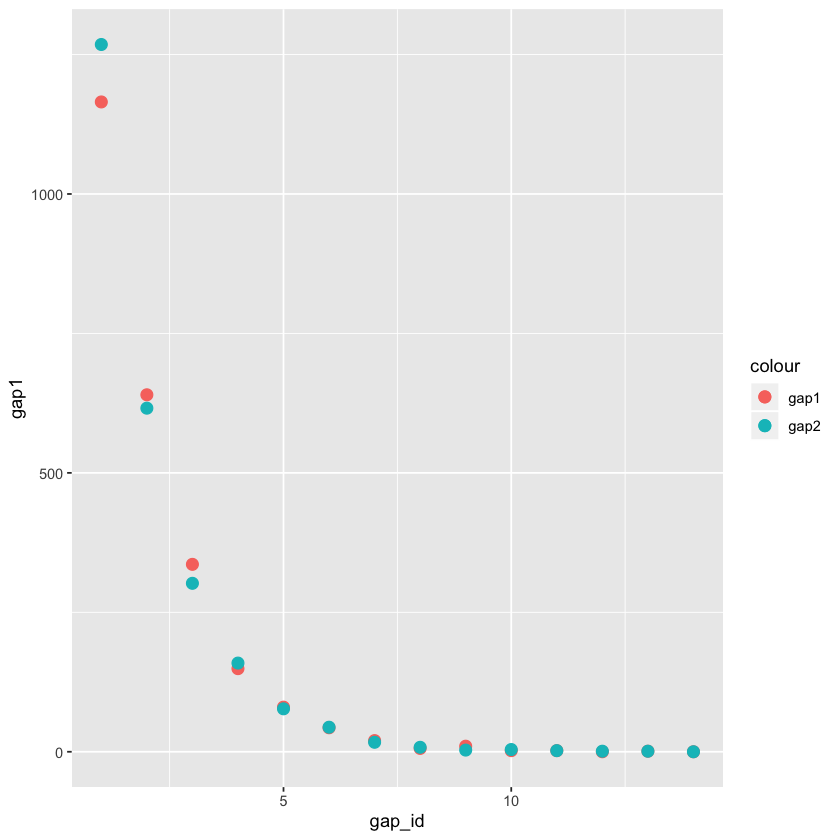

In [148]:
 ggplot(gap.data, aes(gap_id),fill = variable) + 
    geom_point(aes(y = gap1, colour = "gap1"),size=3) + 
    geom_point(aes(y = gap2, colour = "gap2"),size=3) 

In [33]:
chisq.test(rbind(gap1$observed, gap2$observed)[,-length(expected_2)])

Warning message in chisq.test(rbind(gap1$observed, gap2$observed)[, -length(expected_2)]):
“Chi-squared approximation may be incorrect”



	Pearson's Chi-squared test

data:  rbind(gap1$observed, gap2$observed)[, -length(expected_2)]
X-squared = 13, df = 12, p-value = 0.4


### 2.3.2 Serial Tests

In [18]:
ser_1=serial.test(mydata$X1)


			 Serial test

chisq stat = 44, df = 63, p-value = 0.97

		 (sample size : 10000)

	observed number	 87 67 87 79 79 82 75 84 77 63 84 89 82 79 69 91 75 79 82 80 82 86 62 71 68 78 82 82 84 81 87 77 82 78 94 64 81 69 83 82 71 68 79 81 78 68 68 76 89 75 78 83 72 85 71 69 72 85 63 88 79 80 82 77 
	expected number	 78 


In [19]:
ser_2=serial.test(mydata$X2)


			 Serial test

chisq stat = 64, df = 63, p-value = 0.45

		 (sample size : 10000)

	observed number	 94 79 74 82 76 76 69 75 76 61 94 82 76 81 75 73 68 84 95 78 78 83 77 73 71 73 67 77 68 69 86 77 72 69 81 70 92 66 82 69 82 90 73 83 89 67 73 99 92 72 74 99 79 72 73 75 73 74 86 76 101 77 84 69 
	expected number	 78 


In [26]:
ser_obs_1=ser_1$observed
ser_obs_1

[1] 87 67 87 79 79 82 75 84 77 63 84 89 82 79 69 91 75 79 82 80 82 86 62 71 68
[26] 78 82 82 84 81 87 77 82 78 94 64 81 69 83 82 71 68 79 81 78 68 68 76 89 75
[51] 78 83 72 85 71 69 72 85 63 88 79 80 82 77

In [27]:
ser_obs_2=ser_2$observed
ser_obs_2

[1]  94  79  74  82  76  76  69  75  76  61  94  82  76  81  75  73  68  84  95
[20]  78  78  83  77  73  71  73  67  77  68  69  86  77  72  69  81  70  92  66
[39]  82  69  82  90  73  83  89  67  73  99  92  72  74  99  79  72  73  75  73
[58]  74  86  76 101  77  84  69

In [150]:
ser.data <- data.frame(
   ser_id = c (1:length(ser_1$observed)), 
   ser1 = c(ser_1$observed), 
   ser2 = c(ser_2$observed))
ser.data

ser_id,ser1,ser2
<int>,<int>,<int>
1,87,94
2,67,79
3,87,74
4,79,82
5,79,76
6,82,76
7,75,69
8,84,75
9,77,76


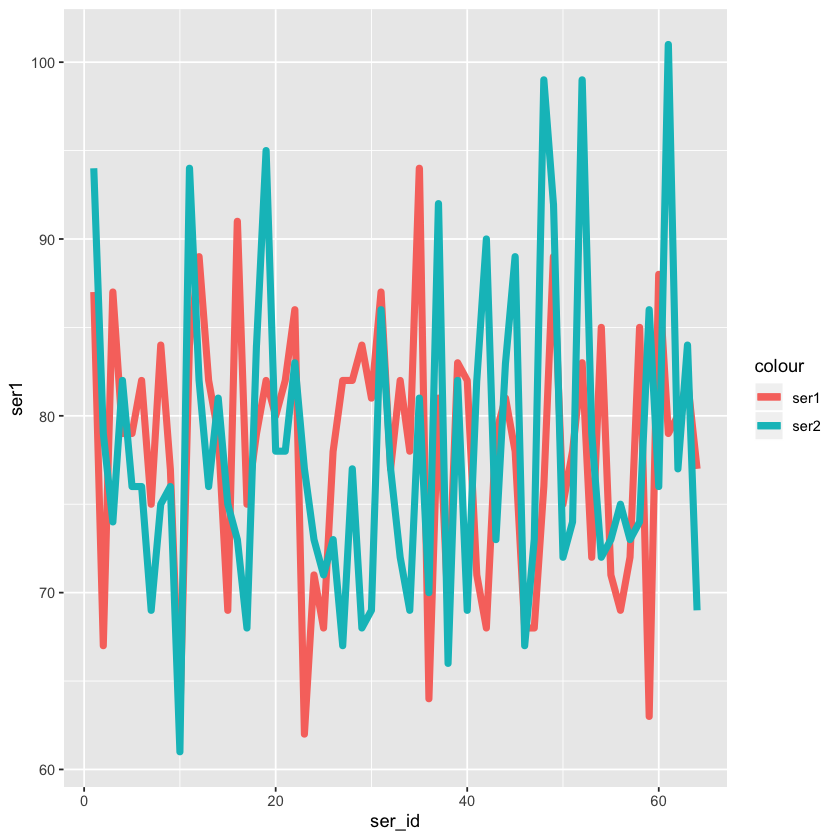

In [155]:
ggplot(ser.data, aes(ser_id)) + 
    geom_line(aes(y = ser1, colour = "ser1"),size=2) + 
    geom_line(aes(y = ser2, colour = "ser2"),size=2) 

In [28]:
chisq.test(rbind(ser_obs_1, ser_obs_2))


	Pearson's Chi-squared test

data:  rbind(ser_obs_1, ser_obs_2)
X-squared = 39, df = 63, p-value = 1


### 2.3.3 Equidistribution Test (Frequence Test)

In [36]:
freq_1=freq.test(mydata$X1)


			 Frequency test

chisq stat = 7.9, df = 15, p-value = 0.93

		 (sample size : 10000)

	observed number	 620 641 607 620 609 657 645 640 630 640 593 626 596 623 638 615 
	expected number	 625 


In [37]:
freq_2=freq.test(mydata$X2)


			 Frequency test

chisq stat = 7.3, df = 15, p-value = 0.95

		 (sample size : 10000)

	observed number	 626 627 595 625 645 635 599 636 610 650 607 640 609 646 636 614 
	expected number	 625 


In [156]:
freq.data <- data.frame(
   freq_id = c (1:length(freq_1$observed)), 
   freq1 = c(freq_1$observed), 
   freq2 = c(freq_2$observed))
freq.data

freq_id,freq1,freq2
<int>,<int>,<int>
1,620,626
2,641,627
3,607,595
4,620,625
5,609,645
6,657,635
7,645,599
8,640,636
9,630,610


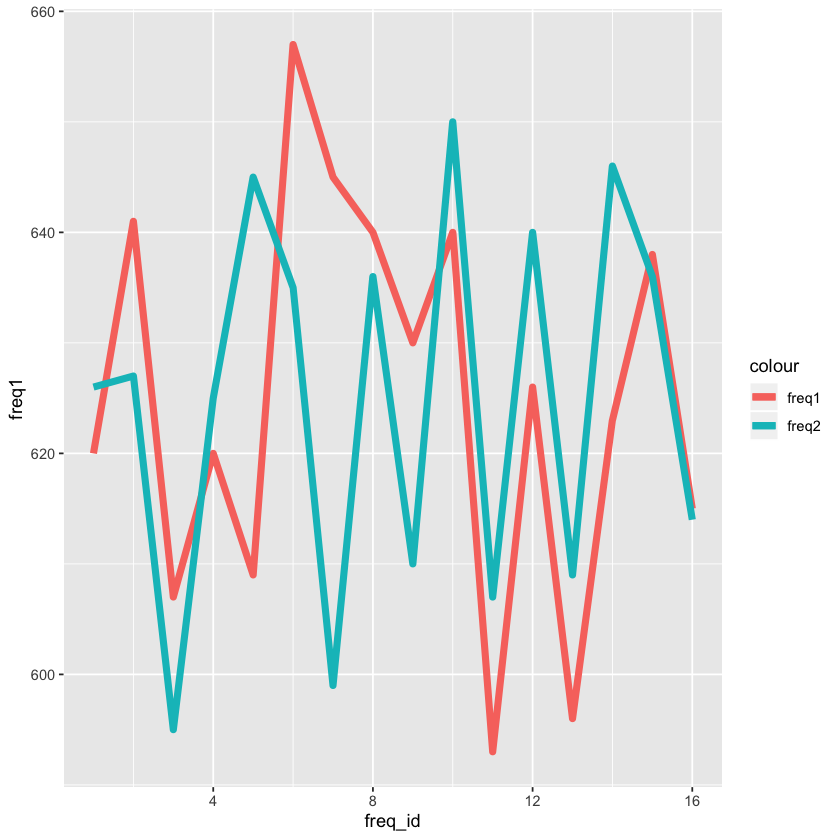

In [159]:
ggplot(freq.data, aes(freq_id)) + 
    geom_line(aes(y = freq1, colour = "freq1"),size=2) + 
    geom_line(aes(y = freq2, colour = "freq2"),size=2) 

In [38]:
chisq.test(rbind(freq_1$observed, freq_2$observed))


	Pearson's Chi-squared test

data:  rbind(freq_1$observed, freq_2$observed)
X-squared = 5, df = 15, p-value = 1


## 3 - Conclusion
#### 1. Compare statistically and graphically the two given random sequences X1 and X2.
    Method:
    Here, I use Correlation Test, Chi-squared Test（chisq.test）, Kolmogorov–Smirnov test (ks.test) and Empirical Tests ( Gap Test (gap.test), Serial Test (serial.test), Equidistribution Test (Frequence Test-freq.test)) to test these two random sequeueces.
           
#### 2. Are the given sequences X1 and X2 potentially drawn from the same RNG ?
    Yes 
        
#### 3. Motivate your answer with arguments taken from the Computational Statistics Course.
    1)According to Cumulative Distribution Function shown below, these two functions are Uniform distribution (continuous) 
    Unif(0,1).
   ![title](ECDFX.png)
   
    2)According to result of test.
    [Null hypothesis]: both samples come from the same distribution. 
    [Result]: not rejected (all p-value > 0.05) since they do come from the exact same distribution.
      
      Result:
   ![title](AllResult.png)
          
          
           

## 4 - Acknowledgement

    I would like to express my special thanks of gratitude to Prof. Raymond Bisdorff who gave me the golden  opportunity to do this wonderful project. I have chosen all courses given by Prof. Raymond Bisdorff during my master study and learn many methods to make decision and do stastical test. I came to know about so many new things. Thank you Prof. Raymond Bisdorff.

## 5- Reference:
    [1] http://www.physics.csbsju.edu/stats/KS-test.html
    [2] https://davetang.org/muse/2012/04/17/comparing-different-distributions/
    [3] Slides provided by Prof. Raymond Bisdorff